### **1. Nhập thư viện và dữ liệu**

In [3]:
#Thư viện xử lý dữ liệu
import pandas as pd
import numpy as np
from pathlib import Path

#Thư viện preprocessing và modeling
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier 
from sklearn import metrics 
import joblib 


In [4]:
path = Path('data') / 'AIML Dataset.csv'
data = pd.read_csv(path)

### **2. Feature Engineering và Preprocessing**

Loại bỏ các biến không dùng đến trong mô hình:

Dựa vào kết quả của EDA, ta sẽ tạo biến hour thể hiện khung giờ giao dịch: 

In [5]:
data['hour'] = data['step'] % 24

In [6]:
data = data.drop(columns = ['step', 'nameOrig', 'nameDest', 'isFlaggedFraud'] )

Encode các biến chữ:

In [7]:
le = LabelEncoder()
data['type'] = le.fit_transform(data['type'])
data.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,hour
0,3,9839.64,170136.0,160296.36,0.0,0.0,0,1
1,3,1864.28,21249.0,19384.72,0.0,0.0,0,1
2,4,181.00,181.0,0.00,0.0,0.0,1,1
3,1,181.00,181.0,0.00,21182.0,0.0,1,1
4,3,11668.14,41554.0,29885.86,0.0,0.0,0,1


Chia tệp train - test: 

In [8]:
x = data.drop(columns = ['isFraud'])
y = data['isFraud']
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.3, stratify = y, random_state =0)


Từ kết luận của EDA, ta thấy biến isFraud có vấn đề class imbalance nghiêm trọng. Một số giải pháp có thể sử dụng: 
- **Resample**: downsample xuống tỉ lệ 20:1, 15:1 hoặc 10:1 do bộ dữ liệu có 6 triệu quan sát, trong khi chỉ có vài nghìn Fraud
- **SMOTE**: tạo thêm quan sát cho class Fraud 

-> Vì bộ dữ liệu có 6 triệu quan sát nên **tôi chọn downsample để đẩy nhanh tốc độ train model**, tuy nhiên trong thực tiễn, SMOTE sẽ mang lại kết quả tốt hơn.

In [9]:
train = pd.concat([xtrain, ytrain], axis=1)

fraud = train[train["isFraud"] == 1]
nonfraud = train[train["isFraud"] == 0]

nonfraud_down = resample(
    nonfraud,
    replace=False,
    n_samples=len(fraud) *20,
    random_state=42
)

train_down = pd.concat([fraud, nonfraud_down]).sample(frac=1, random_state=42) .reset_index(drop=True)

xtrain_down = train_down.drop(columns="isFraud")
ytrain_down = train_down["isFraud"]

### **3. Train model**

**Random Forest** và **XGBoost** sẽ được train để phân biệt Fraud và Non-Fraud. Các mô hình tuyến tính như Logistic regression sẽ không được sử dụng theo như kết quả từ EDA.  

In [10]:
models = {
    'XGBoost': {
        'model' : XGBClassifier(objective = 'binary:logistic', random_state = 0),
        'para' : {'max_depth' : [2,4,6], 'min_child_weight': [1, 3, 5], 'n_estimators' : [50, 75, 100], 'learning_rate' : [0.05, 0.1, 0.2]}
    }, 
    'Random Forest' : {
        'model' : RandomForestClassifier(random_state = 0),
        'para' : {'max_depth' : [2,4,6], 'min_samples_leaf': [1, 5], 'n_estimators' : [50, 75], 'min_samples_split' : [2,10], 'max_features': ['sqrt']}
    }
}

Fit tệp train và tạo bảng:

In [ ]:
best_model = []
best_estimator = []
for name, config in models.items():
    grid = GridSearchCV(config['model'], config['para'],cv = 5, scoring = 'f1', refit = 'f1', n_jobs = -1)
    grid.fit(xtrain_down, ytrain_down)
    f1 = grid.best_score_
    best = grid.best_estimator_
    best_estimator.append(best)
    best_model.append({
            'model': name,
            'f1': f1, 
        })
    print(f'Mô hình {name} train thành công!' )
    
table = pd.DataFrame(best_model)

Mô hình XGBoost train thành công!
Mô hình Random Forest train thành công!


In [12]:
table

,model,f1
0,XGBoost,0.969137
1,Random Forest,0.888187


Có thể thấy, sử dụng metric là f1, sau khi cross validate thì mô hình **XGBoost chính xác hơn** trong việc phân loại Fraud, Non-Fraud 

-> Mô hình lựa chọn: **XGBoost**

Lưu mô hình:

In [13]:
joblib.dump(best_estimator[0],'models/xgboost.pickle')

['models/xgboost.pickle']

### **3. Fit tệp test lên model và kiểm tra khả năng dự đoán**

Load mô hình: 

In [14]:
xgb = joblib.load('models/xgboost.pickle')

Fit tệp test:

In [15]:
ypred = xgb.predict(xtest)

Confusion matrix: 

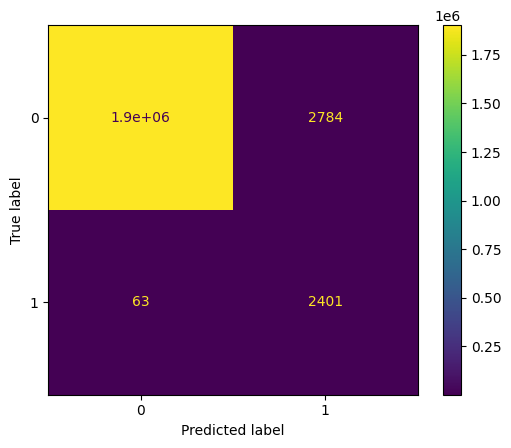

In [16]:
cm = metrics.confusion_matrix(ytest, ypred, labels = xgb.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = xgb.classes_)
disp.plot()

- Có thể thấy: khả năng dự đoán **tương đối cao**, chỉ bị miss 63 giao dịch fraud. 

- Tuy nhiên, mô hình có lượng dương tính giả khá cao (2784 giao dịch)

Classification report:

In [17]:
print(metrics.classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.46      0.97      0.63      2464

    accuracy                           1.00   1908786
   macro avg       0.73      0.99      0.81   1908786
weighted avg       1.00      1.00      1.00   1908786



=> Kết luận: Trên tệp test:
- Mô hình perform khá tốt, **chỉ miss 63 giao dịch fraud trên tổng ~ 2500 giao dịch fraud**
- Tuy nhiên mô hình **có xu hướng classify khá nhiều giao dịch NonFraud**

=> **điều này có thể đến từ việc downsample** được thực hiện trong quá trình preprocess. Tuy nhiên, do bộ dữ liệu có 6 triệu quan sát và để đẩy nhanh tốc độ train mô hình, tôi chấp nhận đánh đổi.